# 花式索引：


前几章讨论了如何使用简单索引（例如，`arr[0]`）、切片（例如，`arr[:5]`）和布尔掩码（例如，`arr[arr > 0]`）来访问和修改数组的部分内容。

在本章中，我们将探讨另一种数组索引风格，称为*花式*或*向量化*索引，其中我们用索引数组代替单个标量。

这使我们能够非常快速地访问和修改数组值的复杂子集。

## 探索花式索引

花式索引的概念非常简单：它意味着传递一个索引数组，以便一次访问多个数组元素。

例如，考虑以下数组：

In [5]:
import numpy as np
rng = np.random.default_rng(seed=1701)

x = rng.integers(100, size=10)
print(x)

[90 40  9 30 80 67 39 15 33 79]


假设我们想要访问三个不同的元素。我们可以这样做：

In [6]:
[x[3], x[7], x[2]]

[np.int64(30), np.int64(15), np.int64(9)]

另外，我们可以传递一个单一的索引列表或数组，以获得相同的结果：

In [7]:
ind = [3, 7, 4]
x[ind]

array([30, 15, 80])

使用索引数组时，结果的形状反映的是*索引数组*的形状，而不是*被索引数组*的形状。

In [8]:
ind = np.array([[3, 7],
                [4, 5]])
x[ind]

array([[30, 15],
       [80, 67]])

花式索引在多维数组中同样适用。请考虑以下数组：

In [9]:
X = np.arange(12).reshape((3, 4))
X

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

与标准索引类似，第一个索引指的是行，第二个索引指的是列。

In [10]:
row = np.array([0, 1, 2])
col = np.array([2, 1, 3])
X[row, col]

array([ 2,  5, 11])

请注意，结果中的第一个值是 `X[0, 2]`，第二个值是 `X[1, 1]`，第三个值是 `X[2, 3]`。

在花式索引中，索引的配对遵循所有在 [Computation on Arrays: Broadcasting](02.05-Computation-on-arrays-broadcasting.ipynb) 中提到的广播规则。

例如，如果我们将列向量和行向量结合在索引中，我们会得到一个二维结果。

In [12]:
X[row[:, np.newaxis], col]

array([[ 2,  1,  3],
       [ 6,  5,  7],
       [10,  9, 11]])

在这里，每个行值与每个列向量相匹配，正如我们在算术运算的广播中所看到的那样。

例如：

In [13]:
row[:, np.newaxis] * col

array([[0, 0, 0],
       [2, 1, 3],
       [4, 2, 6]])

始终要记住，使用花式索引时，返回值反映的是*索引的广播形状*，而不是被索引数组的形状。

## 组合索引

为了实现更强大的操作，花式索引可以与我们之前看到的其他索引方案结合使用。例如，给定数组 `X`：

In [14]:
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


我们可以结合复杂和简单的指标：

In [15]:
X[2, [2, 0, 1]]

array([10,  8,  9])

我们还可以将花式索引与切片结合使用：

In [16]:
X[1:, [2, 0, 1]]

array([[ 6,  4,  5],
       [10,  8,  9]])

我们可以将花式索引与掩码结合使用：

In [17]:
mask = np.array([True, False, True, False])
X[row[:, np.newaxis], mask]

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

所有这些索引选项的结合，形成了一组非常灵活的操作，可以高效地访问和修改数组值。

## 示例：选择随机点

一种常见的高级索引用法是从矩阵中选择行的子集。

例如，我们可能有一个 $N$ 行 $D$ 列的矩阵，表示在 $D$ 维空间中的 $N$ 个点，例如以下从二维正态分布中抽取的点：

In [18]:
mean = [0, 0]
cov = [[1, 2],
       [2, 5]]
X = rng.multivariate_normal(mean, cov, 100)
X.shape

(100, 2)

使用我们将在[Matplotlib简介](04.00-Introduction-To-Matplotlib.ipynb)中讨论的绘图工具，我们可以将这些点可视化为散点图（见下图）：

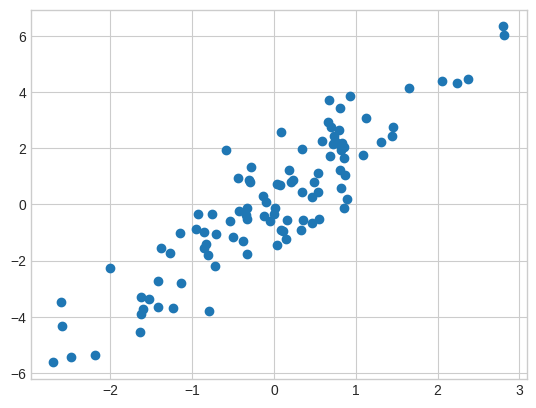

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

plt.scatter(X[:, 0], X[:, 1]);

让我们使用花式索引来选择20个随机点。我们将首先选择20个不重复的随机索引，然后利用这些索引从原始数组中选取一部分：

In [21]:
indices = np.random.choice(X.shape[0], 20, replace=False)
indices

array([99, 24, 30, 27, 72, 88, 93, 75, 92, 66, 41, 81, 48, 90,  6, 83, 71,
       53, 85, 74])

In [22]:
selection = X[indices]  # fancy indexing here
selection.shape

(20, 2)

现在，为了查看选择了哪些点，我们将在所选点的位置上叠加大圆圈（见下图）：

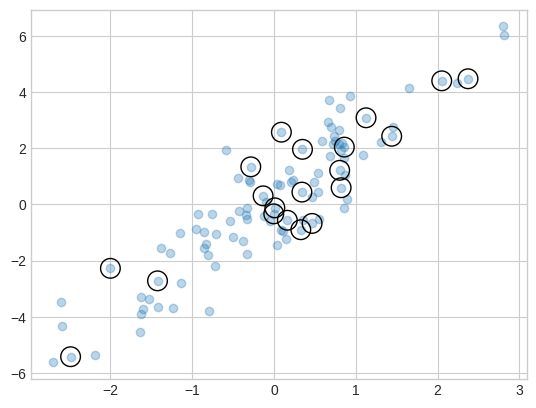

In [23]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
plt.scatter(selection[:, 0], selection[:, 1],
            facecolor='none', edgecolor='black', s=200);

这种策略通常用于快速划分数据集，这在进行训练/测试拆分以验证统计模型时（见[超参数和模型验证](05.03-Hyperparameters-and-Model-Validation.ipynb)）以及在回答统计问题的抽样方法中常常是必要的。

## 使用花式索引修改值

花式索引不仅可以用于访问数组的部分元素，还可以用于修改数组的部分元素。

例如，假设我们有一个索引数组，我们希望将对应的数组项设置为某个值：

In [24]:
x = np.arange(10)
i = np.array([2, 1, 8, 4])
x[i] = 99
print(x)

[ 0 99 99  3 99  5  6  7 99  9]


我们可以为此使用任何赋值类型的运算符。例如：

In [25]:
x[i] -= 10
print(x)

[ 0 89 89  3 89  5  6  7 89  9]


请注意，重复的索引在这些操作中可能会导致一些潜在的意外结果。考虑以下内容：

In [26]:
x = np.zeros(10)
x[[0, 0]] = [4, 6]
print(x)

[6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


4去哪儿了？这个操作首先将`x[0]`赋值为4，然后再将其赋值为6。

结果显然是，`x[0]`的值为6。

这没问题，但请考虑以下操作：

In [21]:
i = [2, 3, 3, 4, 4, 4]
x[i] += 1
x

array([6., 0., 1., 1., 1., 0., 0., 0., 0., 0.])

你可能会期待 `x[3]` 的值为 2，`x[4]` 的值为 3，因为这正是每个索引被重复的次数。为什么情况并非如此？

从概念上讲，这是因为 `x[i] += 1` 是 `x[i] = x[i] + 1` 的简写形式。首先计算 `x[i] + 1`，然后将结果赋值给 `x` 中的相应索引。

考虑到这一点，并不是增量操作发生了多次，而是赋值操作导致了这种不太直观的结果。

那么，如果你想要重复执行该操作，该怎么办呢？为此，你可以使用 ufuncs 的 `at` 方法，如下所示：

In [27]:
x = np.zeros(10)
np.add.at(x, i, 1)
print(x)

[0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]


`at` 方法在指定的索引（此处为 `i`）上对给定操作符进行就地应用，并使用指定值（此处为 1）。

另一个类似的方法是 ufuncs 的 `reduceat` 方法，您可以在 [NumPy 文档](https://numpy.org/doc/stable/reference/ufuncs.html) 中阅读相关内容。

## 示例：数据分箱

您可以利用这些思路高效地对数据进行自定义分箱计算。

例如，假设我们有100个值，并希望快速找到它们在一组区间中的位置。

我们可以使用 `ufunc.at` 进行如下计算：

In [28]:
rng = np.random.default_rng(seed=1701)
x = rng.normal(size=100)

# compute a histogram by hand
bins = np.linspace(-5, 5, 20)
counts = np.zeros_like(bins)

# find the appropriate bin for each x
i = np.searchsorted(bins, x)

# add 1 to each of these bins
np.add.at(counts, i, 1)

计数现在反映了每个区间内的点数——换句话说，这是一个直方图（见下图）：

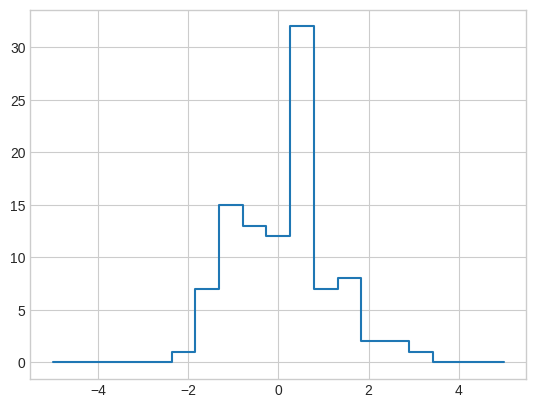

In [29]:
# plot the results
plt.plot(bins, counts, drawstyle='steps');

当然，每次想要绘制直方图时都这样做会很不方便。

因此，Matplotlib 提供了 `plt.hist` 例程，它可以在一行代码中完成相同的操作：

```python
plt.hist(x, bins, histtype='step');
```

这个函数将生成与刚才展示的图几乎完全相同的图形。

为了计算分箱，Matplotlib 使用 `np.histogram` 函数，该函数执行的计算与我们之前所做的非常相似。让我们在这里比较一下这两者：

In [30]:
print(f"NumPy histogram ({len(x)} points):")
%timeit counts, edges = np.histogram(x, bins)

print(f"Custom histogram ({len(x)} points):")
%timeit np.add.at(counts, np.searchsorted(bins, x), 1)

NumPy histogram (100 points):
4.35 μs ± 25.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Custom histogram (100 points):
3.83 μs ± 29.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


我们的单行算法速度是NumPy优化算法的两倍！这怎么可能呢？如果你深入研究`np.histogram`的源代码（在IPython中输入`np.histogram??`可以查看），你会发现它比我们所做的简单搜索和计数要复杂得多；这是因为NumPy的算法更灵活，特别是在数据点数量较大时，它被设计为具有更好的性能。

In [31]:
x = rng.normal(size=1000000)
print(f"NumPy histogram ({len(x)} points):")
%timeit counts, edges = np.histogram(x, bins)

print(f"Custom histogram ({len(x)} points):")
%timeit np.add.at(counts, np.searchsorted(bins, x), 1)

NumPy histogram (1000000 points):
4.37 ms ± 65 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Custom histogram (1000000 points):
33.2 ms ± 363 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


这段比较显示，算法效率几乎从来不是一个简单的问题。对于大数据集有效的算法并不总是适合小数据集，反之亦然（见[大O符号](02.08-Sorting.ipynb#Big-O-Notation)）。

然而，自行编写该算法的优势在于，通过理解这些基本方法，你可以自由发挥：不再受限于内置例程，而是能够创造自己的数据探索方法。

在数据密集型应用中高效使用Python的关键，不仅在于了解像`np.histogram`这样的通用便利例程及其适用时机，还包括知道如何利用低级功能以满足更具体的需求。